# CNN Multi Dim Analysis

### Imports, datasets and types

In [2]:
%load_ext autoreload
%autoreload 2

import gc
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import Tensor, nn

sys.path.insert(0, os.path.join(os.path.abspath(os.pardir), "src"))
from molearn.analysis import MolearnAnalysis
from molearn.analysis.plot import *
from molearn.data import PDBData
from molearn.models.CNN_autoencoder import AutoEncoder, FromND, ToND

device: str = "cuda" if torch.cuda.is_available() else "cpu"
atoms: list[str] = ["N", "CA", "C", "O", "CB"]

with open("../data/data_statistics_full.json") as f:
    stats = json.load(f)

mean: float = stats["mean"]
std: float = stats["std"]

data_closed = PDBData(
    filename=["../data/full_murd_closed.pdb"],
    atoms=atoms,
    fix_terminal=True,
)
_: Tensor = data_closed.prepare_dataset(mean=mean, std=std)


data_open = PDBData(
    filename=["../data/full_murd_open.pdb"],
    atoms=atoms,
    fix_terminal=True,
)
_: Tensor = data_open.prepare_dataset(mean=mean, std=std)

data_both = PDBData(
    filename=["../data/full_murd_both.pdb"],
    atoms=atoms,
    fix_terminal=True,
)
_: Tensor = data_both.prepare_dataset(mean=mean, std=std)

data_test = PDBData(
    filename=["../data/full_murd_test.pdb"],
    atoms=atoms,
    fix_terminal=True,
)

_: Tensor = data_test.prepare_dataset(mean=mean, std=std)


PlotData = list[tuple[str, ...]]

Using pre-computed mean: 17.09642555407783, std: 23.559262743825876
Dataset shape: torch.Size([2000, 2145, 3])
Using pre-computed mean: 17.09642555407783, std: 23.559262743825876
Dataset shape: torch.Size([2000, 2145, 3])
Using pre-computed mean: 17.09642555407783, std: 23.559262743825876
Dataset shape: torch.Size([4000, 2145, 3])
Using pre-computed mean: 17.09642555407783, std: 23.559262743825876
Dataset shape: torch.Size([1600, 2145, 3])


### Loading results

In [3]:
BASE_PATH: str = r"../results/11-feb-2026-latent-dim-physics"
RUNS: list[int] = list(range(1, 6))
ALL_VARS: list[int] = list(range(2, 17))
N_ATOMS: int = 2145
RANDOM_STATE: int = 42
CLOSED_COLOR: str = "#AFC2DC"
OPEN_COLOR: str = "#FDBFCA"
BOTH_COLOR: str = "#FDBFCA"
TEST_COLOR: str = "#7FB069"


log_dfs: dict[int, dict[int, pd.DataFrame]]
min_valid_losses: dict[int, dict[int, float]]
min_valid_mse_losses: dict[int, dict[int, float]]
models: dict[int, dict[int, AutoEncoder]]
MAs: dict[int, dict[int, MolearnAnalysis]]

log_dfs, min_valid_losses, min_valid_mse_losses, models, MAs = (
    {t: {} for t in RUNS} for _ in range(5)
)


for t in RUNS:
    for var in ALL_VARS:
        log_dfs[t][var] = pd.read_csv(Path(f"{BASE_PATH}/{t}/{var}/log.dat"))
        best_epoch: int = log_dfs[t][var]["valid_loss"].idxmin()  # type: ignore[assignment]
        min_valid_losses[t][var] = min(log_dfs[t][var].valid_loss)
        min_valid_mse_losses[t][var] = min(log_dfs[t][var].valid_mse_loss)

        checkpoint_path: Path = Path(f"{BASE_PATH}/{t}/{var}/checkpoint_converged.ckpt")
        checkpoint: dict = torch.load(
            checkpoint_path, map_location=device, weights_only=False
        )

        model: AutoEncoder = AutoEncoder(n_atoms=N_ATOMS, latent_dim=var)
        model.load_state_dict(checkpoint["model_state_dict"])

        models[t][var] = model

        MA: MolearnAnalysis = MolearnAnalysis()
        MA.batch_size = 16
        MA.processes = 4

        MA.set_dataset(data=data_open, key="train_open")
        MA.set_dataset(data=data_closed, key="train_closed")
        MA.set_dataset(data=data_both, key="train_both")
        MA.set_dataset(data=data_test, key="test_trans")

        MA.set_network(models[t][var])

        MAs[t][var] = MA

## Base plots

#### Encoding and decoding all

In [ ]:
raw_train: dict[int, dict[int, Tensor]]
decoded_train: dict[int, dict[int, Tensor]]

raw_test: dict[int, dict[int, Tensor]]
decoded_test: dict[int, dict[int, Tensor]]

for run in RUNS:
    for var in ALL_VARS:
        out_dir = Path(f"cache/{run}/{var}")
        out_dir.mkdir(parents=True, exist_ok=True)

        torch.save(
            MAs[run][var].get_decoded(key="train_both"), out_dir / "decoded_train.pt"
        )
        torch.save(
            MAs[run][var].get_decoded(key="test_trans"), out_dir / "decoded_test.pt"
        )

        MAs[run][var]._decoded.clear()
        MAs[run][var]._encoded.clear()
        gc.collect()
        torch.cuda.empty_cache()

### Model architecture and shapes

In [ ]:
def print_encoder_shapes(model: AutoEncoder, n_atoms: int) -> None:
    """Print the shape at each stage of the encoder"""
    # Create dummy input: (batch=1, atoms=n_atoms, coords=3)
    x: Tensor = torch.randn(1, n_atoms, 3)

    # Permute to (batch, 3, atoms) as encoder expects
    x = x.permute(0, 2, 1)
    print(f"Input shape: {x.shape}")

    for i, m in enumerate(model.encoder):
        if isinstance(m, ToND):
            # ToND expects unsqueezed input
            x_unsqueezed: Tensor = x.unsqueeze(-1)
            print(f"  After unsqueeze(-1): {x_unsqueezed.shape}")
            x = m(x_unsqueezed)
        else:
            x = m(x)

        # Print shape after certain layer types
        if isinstance(m, (nn.Conv1d, nn.ConvTranspose1d, ToND, FromND)):
            print(f"Layer {i} ({m.__class__.__name__}): {x.shape}")

    print(f"\nFinal latent shape: {x.shape}")


# Test with your model

var: int = 7
run: int = 1

print("=" * 60)
print(f"ENCODER FORWARD PASS - latent_dim={var}")
print("=" * 60)
print_encoder_shapes(models[run][var], n_atoms=N_ATOMS)

In [ ]:
def print_decoder_shapes(model: AutoEncoder, latent_dim: int) -> Tensor:
    """Print the shape at each stage of the decoder"""
    # Create dummy latent input: (batch=1, latent_dim)
    x: Tensor = torch.randn(1, latent_dim)
    print(f"Input latent shape: {x.shape}")

    for i, m in enumerate(model.decoder):
        x = m(x)

        # Print shape after certain layer types
        if isinstance(m, (nn.Conv1d, nn.ConvTranspose1d, ToND, FromND)):
            print(f"Layer {i} ({m.__class__.__name__}): {x.shape}")

    print(f"\nFinal output shape: {x.shape}")
    return x


# Test with your model
var: int = 7
run: int = 1

print("=" * 60)
print(f"DECODER FORWARD PASS - latent_dim={var}")
print("=" * 60)
decoded: Tensor = print_decoder_shapes(models[run][var], var)
print(f"\nExpected atoms: {data_open.dataset.shape[1]}")
print(f"Decoder output atoms: {decoded.shape[2]}")
print(f"Difference: {decoded.shape[2] - data_open.dataset.shape[1]} atoms discarded")

### MSE Plots 

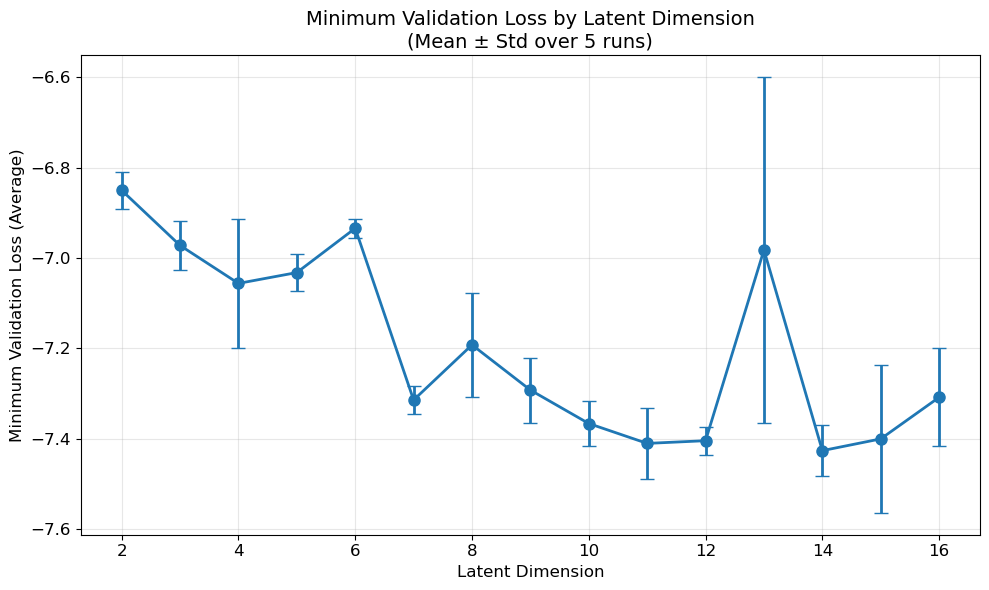

In [ ]:
# Plot line graph of minimum validation losses (averaged over triplicates)

avg_valid_losses: dict[int, float] = {}
std_valid_losses: dict[int, float] = {}

for var in ALL_VARS:
    losses: list[float] = [min_valid_losses[t][var] for t in RUNS]
    avg_valid_losses[var] = float(np.mean(losses))
    std_valid_losses[var] = float(np.std(losses))

plt.figure(figsize=(10, 6))
plt.errorbar(
    list(avg_valid_losses.keys()),
    list(avg_valid_losses.values()),
    yerr=list(std_valid_losses.values()),
    marker="o",
    linewidth=2,
    markersize=8,
    capsize=5,
)
plt.xlabel("Latent Dimension", fontsize=12)
plt.ylabel("Minimum Validation Loss (Average)", fontsize=12)
plt.title(
    "Minimum Validation Loss by Latent Dimension\n(Mean ± Std over 5 runs)",
    fontsize=14,
)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Reconstruction RMSD across Latent Dim

encoding train_both: 250it [00:01, 224.08it/s]
Decoding train_both: 250it [00:01, 132.69it/s]
encoding test_trans: 100it [00:00, 246.17it/s]
Decoding test_trans: 100it [00:00, 125.24it/s]
encoding train_both: 250it [00:00, 308.85it/s]
Decoding train_both: 250it [00:01, 148.96it/s]
encoding test_trans: 100it [00:00, 270.52it/s]
Decoding test_trans: 100it [00:00, 149.67it/s]
encoding train_both: 250it [00:00, 300.92it/s]
Decoding train_both: 250it [00:01, 130.42it/s]
encoding test_trans: 100it [00:00, 288.38it/s]
Decoding test_trans: 100it [00:00, 138.96it/s]
encoding train_both: 250it [00:00, 270.27it/s]
Decoding train_both: 250it [00:01, 145.84it/s]
encoding test_trans: 100it [00:00, 255.52it/s]
Decoding test_trans: 100it [00:00, 128.62it/s]
encoding train_both: 250it [00:00, 256.14it/s]
Decoding train_both: 250it [00:01, 140.76it/s]
encoding test_trans: 100it [00:00, 303.46it/s]
Decoding test_trans: 100it [00:00, 147.70it/s]
encoding train_both: 250it [00:00, 286.01it/s]
Decoding trai

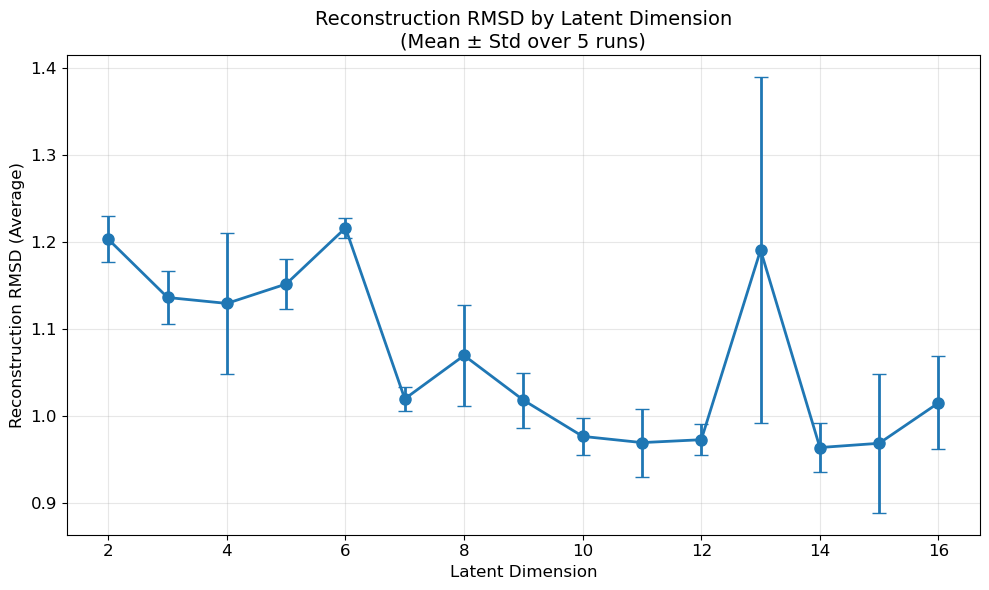

In [4]:
avg_valid_rmsd: dict[int, float] = {}
std_valid_rmsd: dict[int, float] = {}

rows = []


for var in ALL_VARS:
    rmsds: list[float] = []

    for run in RUNS:
        errors_train = MAs[run][var].get_error(key="train_both")
        rmsd_val = float(np.mean(errors_train))
        rmsds.append(rmsd_val)
        rows.append({"var": var, "run": run, "dataset": "train_both", "rmsd": rmsd_val})

        errors_test = MAs[run][var].get_error(key="test_trans")
        rmsd_val_test = float(np.mean(errors_test))
        rows.append(
            {"var": var, "run": run, "dataset": "test_trans", "rmsd": rmsd_val_test}
        )

        MAs[run][var]._decoded.clear()
        MAs[run][var]._encoded.clear()
        gc.collect()
        torch.cuda.empty_cache()

    avg_valid_rmsd[var] = float(np.mean(rmsds))
    std_valid_rmsd[var] = float(np.std(rmsds))

df_rmsd = pd.DataFrame(rows)
df_rmsd_summary = (
    df_rmsd.groupby(["var", "dataset"])["rmsd"].agg(["mean", "std"]).reset_index()
)

df_rmsd_summary.sort_values(["var", "dataset"]).to_csv(
    "../statistics/reconstruction_rmsd.csv", index=False
)

plt.figure(figsize=(10, 6))
plt.errorbar(
    list(avg_valid_rmsd.keys()),
    list(avg_valid_rmsd.values()),
    yerr=list(std_valid_rmsd.values()),
    marker="o",
    linewidth=2,
    markersize=8,
    capsize=5,
)

plt.xlabel("Latent Dimension", fontsize=12)
plt.ylabel("Reconstruction RMSD (Average)", fontsize=12)
plt.title(
    "Reconstruction RMSD by Latent Dimension\n(Mean ± Std over 5 runs)",
    fontsize=14,
)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Model plots

#### Setup

In [ ]:
median_models: list[list[int]] = []

ALL_VARS = list(range(2, 17))

for var in ALL_VARS:
    losses = [(min_valid_losses[t][var], t) for t in RUNS]
    losses.sort()
    median_run = losses[len(losses) // 2][1]
    median_models.append([median_run, var])

print(median_models)

plot_data: PlotData = [
    ("train_both", "Train Both", BOTH_COLOR),
    ("test_trans", "Test Transition", TEST_COLOR),
]

[[4, 2], [4, 3], [2, 4], [5, 5], [4, 6], [3, 7], [4, 8], [2, 9], [3, 10], [1, 11], [5, 12], [5, 13], [5, 14], [5, 15], [5, 16]]


#### RMSD Hist plot

encoding train_both: 250it [00:00, 260.80it/s]
Decoding train_both: 250it [00:02, 117.87it/s]
encoding test_trans: 100it [00:00, 305.36it/s]
Decoding test_trans: 100it [00:00, 127.50it/s]


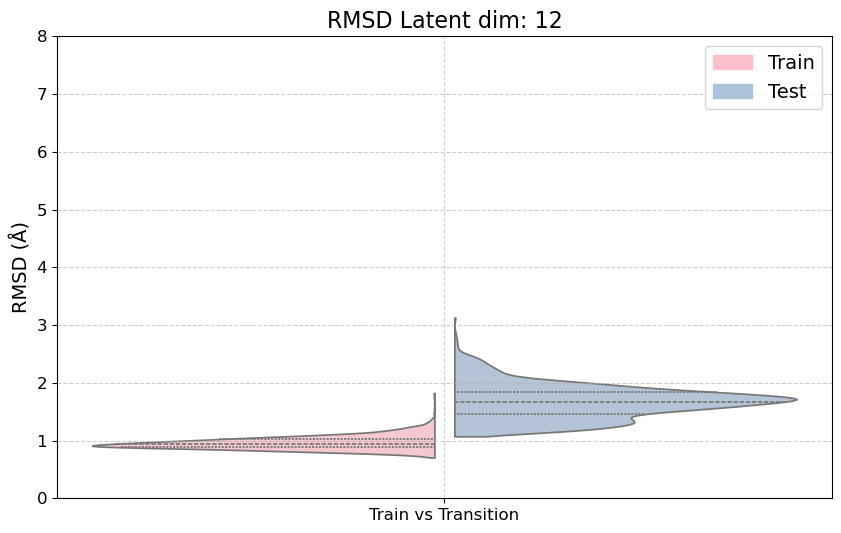

encoding train_both: 250it [00:00, 294.68it/s]
Decoding train_both: 250it [00:01, 125.21it/s]
encoding test_trans: 100it [00:00, 237.81it/s]
Decoding test_trans: 100it [00:00, 100.38it/s]


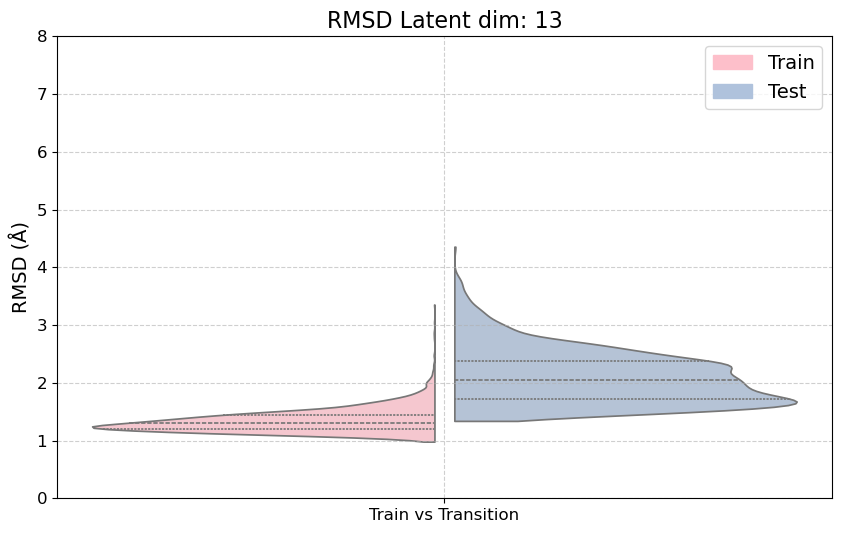

encoding train_both: 250it [00:00, 254.49it/s]
Decoding train_both: 250it [00:02, 99.40it/s] 
encoding test_trans: 100it [00:00, 239.63it/s]
Decoding test_trans: 100it [00:00, 105.37it/s]


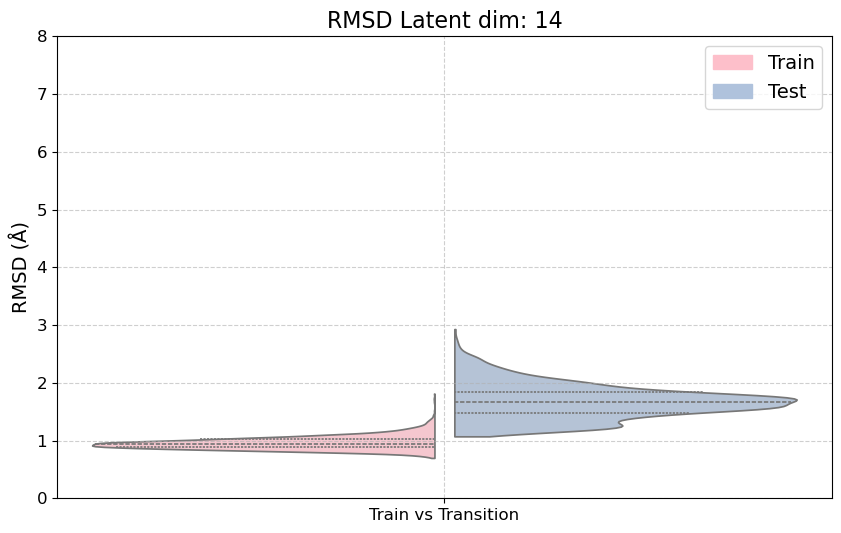

encoding train_both: 250it [00:00, 291.66it/s]
Decoding train_both: 250it [00:02, 110.45it/s]
encoding test_trans: 100it [00:00, 218.13it/s]
Decoding test_trans: 100it [00:01, 97.24it/s]


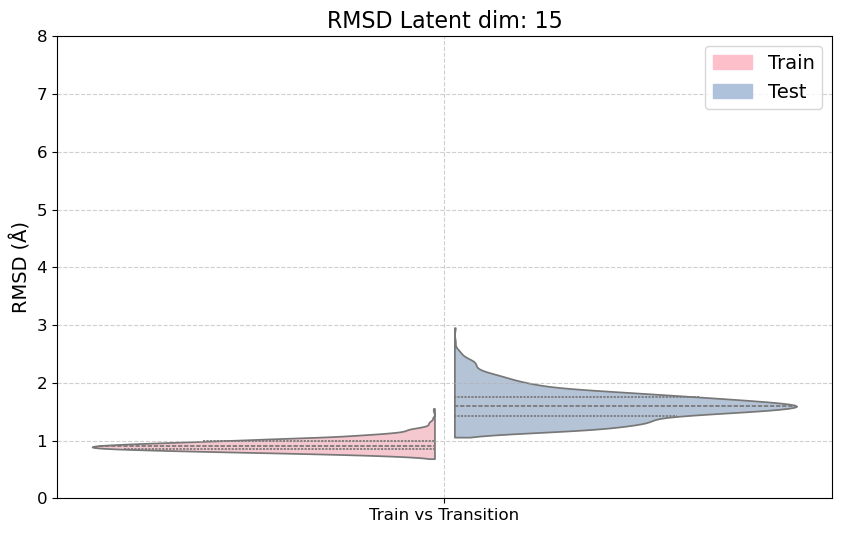

encoding train_both: 250it [00:00, 290.25it/s]
Decoding train_both: 250it [00:01, 131.39it/s]
encoding test_trans: 100it [00:00, 288.17it/s]
Decoding test_trans: 100it [00:00, 129.28it/s]


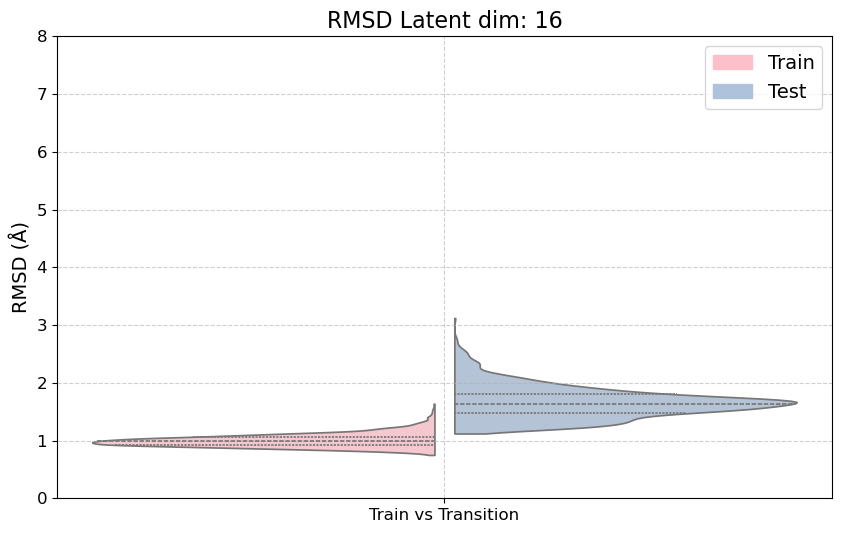

In [15]:
from molearn.analysis.plot import plot_rmsd_hist

for run, var in median_models:
    rmsd_plot_data: PlotData = [
        ("train_both", "test_trans", "Train vs Transition", "train", "test"),
    ]

    plot_rmsd_hist(
        MAs[run][var],
        plot_data=rmsd_plot_data,
        dpi=150,
        var=var,
    )

#### Bond Length Statistics (Wasserstein Distance)

In [10]:
import gc

from utils import get_wasserstein_distances

rows = []

for var in ALL_VARS:
    for run in RUNS:
        wd = get_wasserstein_distances(MAs[run][var], plot_data=plot_data)
        for key, label, _ in plot_data:
            for bond_type, dist in wd[key].items():
                rows.append(
                    {
                        "var": var,
                        "run": run,
                        "dataset": label,
                        "bond_type": bond_type,
                        "wasserstein": dist,
                    }
                )

        MAs[run][var]._decoded.clear()
        MAs[run][var]._encoded.clear()
        gc.collect()
        torch.cuda.empty_cache()


df_wd = pd.DataFrame(rows)

# Average over runs
df_summary = (
    df_wd.groupby(["var", "dataset", "bond_type"])["wasserstein"]
    .agg(["mean", "std"])
    .reset_index()
)

df_summary.sort_values(["var", "dataset", "bond_type"]).to_csv(
    "../statistics/wasserstein_distances.csv", index=False
)

encoding train_both: 250it [00:01, 246.35it/s]
Decoding train_both: 250it [00:01, 155.46it/s]
encoding test_trans: 100it [00:00, 313.12it/s]
Decoding test_trans: 100it [00:00, 186.53it/s]
encoding train_both: 250it [00:00, 288.15it/s]
Decoding train_both: 250it [00:01, 186.23it/s]
encoding test_trans: 100it [00:00, 333.91it/s]
Decoding test_trans: 100it [00:00, 180.15it/s]
encoding train_both: 250it [00:00, 288.63it/s]
Decoding train_both: 250it [00:01, 176.68it/s]
encoding test_trans: 100it [00:00, 334.27it/s]
Decoding test_trans: 100it [00:00, 201.34it/s]
encoding train_both: 250it [00:01, 241.80it/s]
Decoding train_both: 250it [00:01, 139.90it/s]
encoding test_trans: 100it [00:00, 261.25it/s]
Decoding test_trans: 100it [00:00, 170.26it/s]
encoding train_both: 250it [00:00, 308.20it/s]
Decoding train_both: 250it [00:01, 192.22it/s]
encoding test_trans: 100it [00:00, 274.31it/s]
Decoding test_trans: 100it [00:00, 174.82it/s]
encoding train_both: 250it [00:00, 305.59it/s]
Decoding trai

#### Bondlength Hist plots

BOND LENGTH DISTRIBUTIONS - latent_dim=12


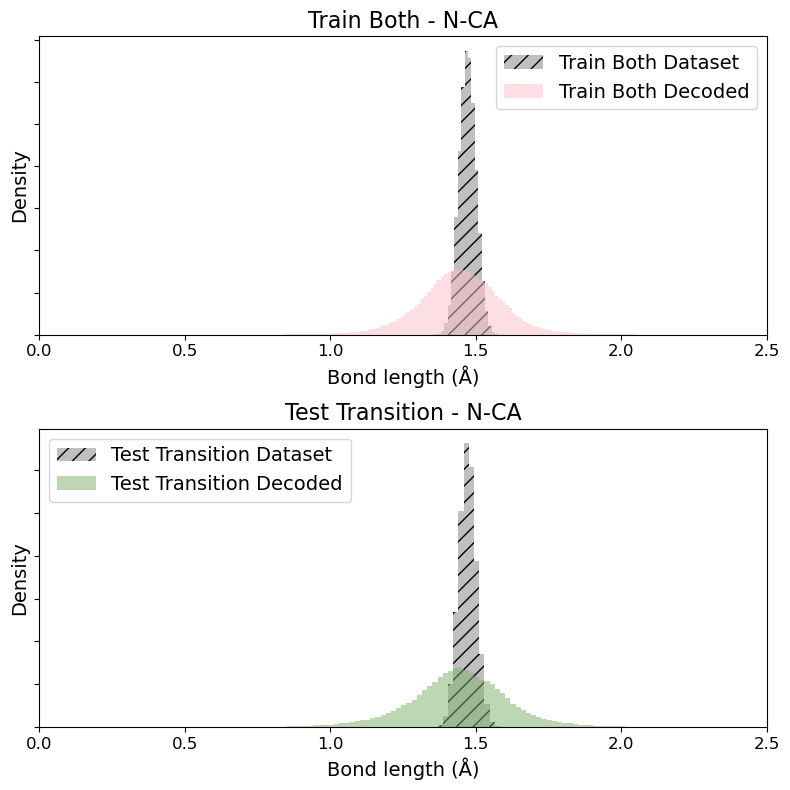

BOND LENGTH DISTRIBUTIONS - latent_dim=13


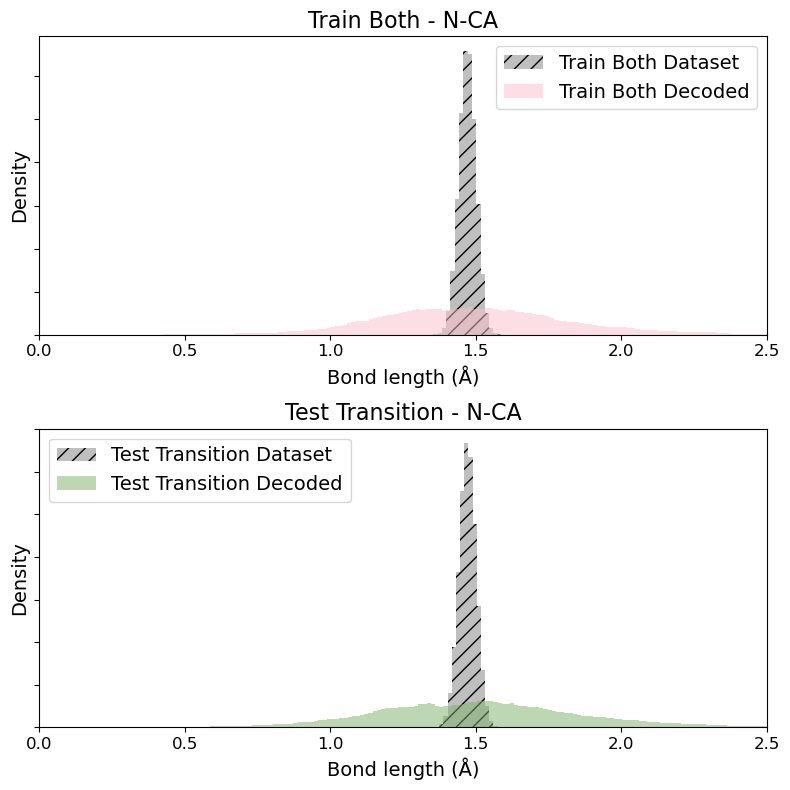

BOND LENGTH DISTRIBUTIONS - latent_dim=14


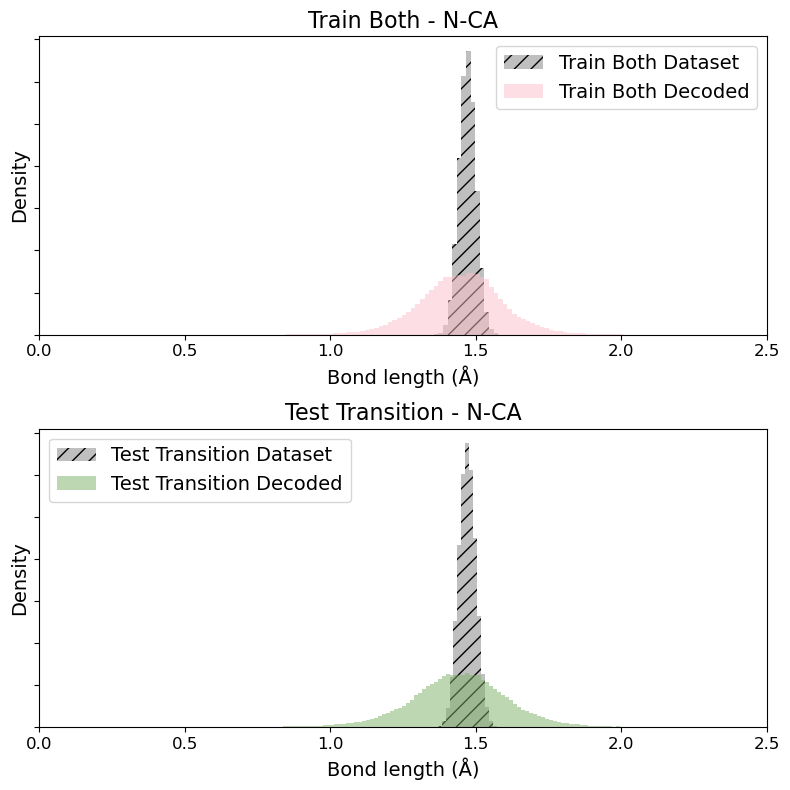

BOND LENGTH DISTRIBUTIONS - latent_dim=15


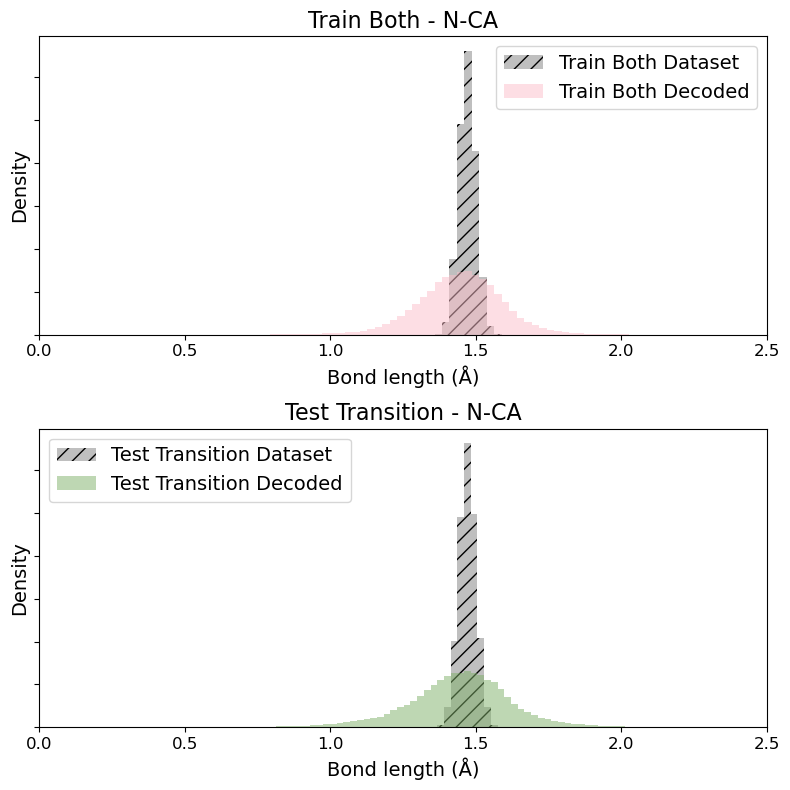

BOND LENGTH DISTRIBUTIONS - latent_dim=16


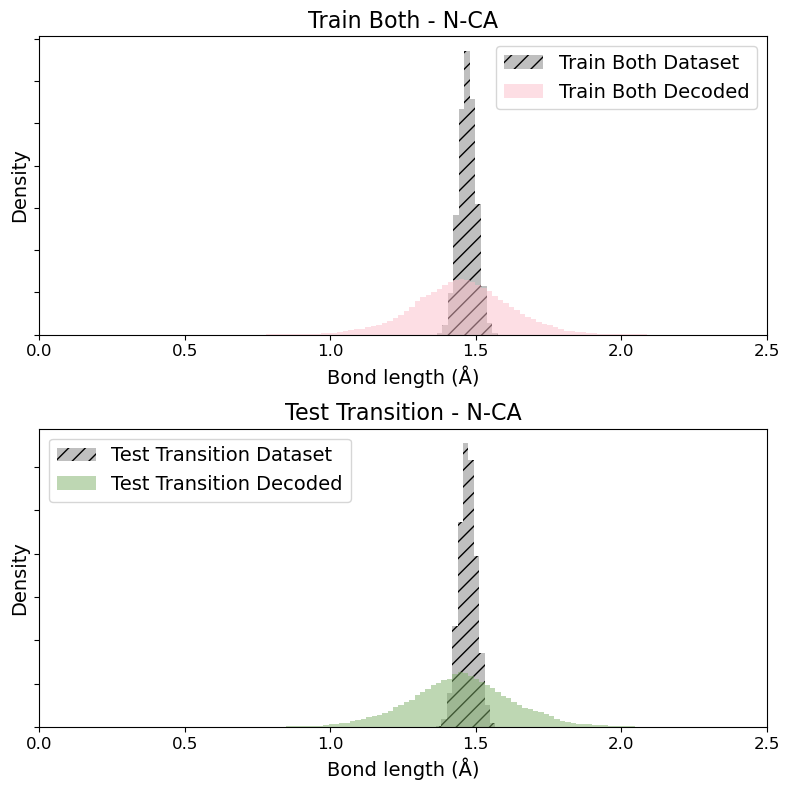

In [16]:
from molearn.analysis.plot import plot_bondlength_hist

for run, var in median_models:
    print("=" * 60)
    print(f"BOND LENGTH DISTRIBUTIONS - latent_dim={var}")
    print("=" * 60)

    plot_bondlength_hist(
        MAs[run][var], plot_data=plot_data, bins=300, dpi=150, bond_types=["N-CA"]
    )

#### Inversion saving statistics


In [6]:
import gc

from utils import get_inversion_ratios

avg_inversion_ratio_train: dict[int, float] = {}
avg_inversion_ratio_test: dict[int, float] = {}
std_inversion_ratio_train: dict[int, float] = {}
std_inversion_ratio_test: dict[int, float] = {}

TARGET_VARS = range(10, 17)

for var in TARGET_VARS:
    rs_train = []
    rs_test = []

    for run in RUNS:
        r1, r2 = get_inversion_ratios(MAs[run][var], plot_data=plot_data)
        rs_train.append(r1)
        rs_test.append(r2)

        MAs[run][var]._decoded.clear()
        MAs[run][var]._encoded.clear()
        gc.collect()
        torch.cuda.empty_cache()

    avg_inversion_ratio_train[var] = round(float(np.mean(rs_train)), 4)
    avg_inversion_ratio_test[var] = round(float(np.mean(rs_test)), 4)
    std_inversion_ratio_train[var] = round(float(np.std(rs_train)), 4)
    std_inversion_ratio_test[var] = round(float(np.std(rs_test)), 4)

rows = [
    {
        "var": var,
        "mean": avg_inversion_ratio_train[var],
        "std": std_inversion_ratio_train[var],
        "train/test": "train",
    }
    for var in TARGET_VARS
] + [
    {
        "var": var,
        "mean": avg_inversion_ratio_test[var],
        "std": std_inversion_ratio_test[var],
        "train/test": "test",
    }
    for var in TARGET_VARS
]

pd.DataFrame(rows).sort_values(["var", "train/test"]).to_csv(
    "../statistics/inversion_ratios3.csv", index=False
)

encoding train_both: 250it [00:00, 270.54it/s]
Decoding train_both: 250it [00:01, 149.86it/s]
encoding test_trans: 100it [00:00, 213.72it/s]
Decoding test_trans: 100it [00:00, 159.52it/s]
encoding train_both: 250it [00:00, 306.32it/s]
Decoding train_both: 250it [00:01, 193.97it/s]
encoding test_trans: 100it [00:00, 320.13it/s]
Decoding test_trans: 100it [00:00, 196.73it/s]
encoding train_both: 250it [00:00, 332.46it/s]
Decoding train_both: 250it [00:01, 188.60it/s]
encoding test_trans: 100it [00:00, 305.28it/s]
Decoding test_trans: 100it [00:00, 191.63it/s]
encoding train_both: 250it [00:00, 309.67it/s]
Decoding train_both: 250it [00:01, 196.37it/s]
encoding test_trans: 100it [00:00, 324.62it/s]
Decoding test_trans: 100it [00:00, 181.76it/s]
encoding train_both: 250it [00:00, 314.21it/s]
Decoding train_both: 250it [00:01, 185.66it/s]
encoding test_trans: 100it [00:00, 314.28it/s]
Decoding test_trans: 100it [00:00, 189.14it/s]
encoding train_both: 250it [00:00, 307.44it/s]
Decoding trai

#### Inversion Hist Plot

INVERSION ERRORS - latent_dim=8, run=2


encoding train_both: 250it [00:01, 170.37it/s]
Decoding train_both: 250it [00:02, 105.27it/s]
encoding test_trans: 100it [00:00, 190.53it/s]
Decoding test_trans: 100it [00:00, 108.78it/s]


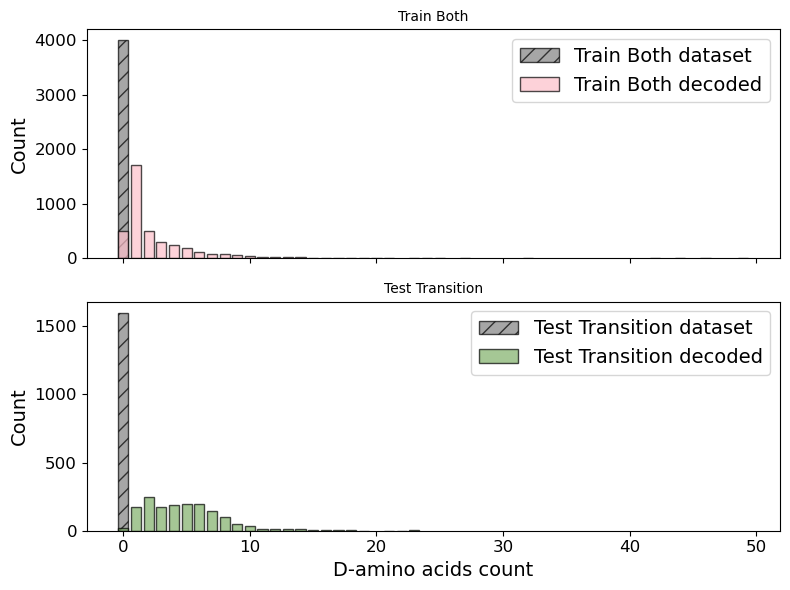

(0.12425, 0.01125)


In [10]:
for run, var in median_models:
    print("=" * 60)
    print(f"INVERSION ERRORS - latent_dim={var}, run={run}")
    print("=" * 60)

    plot_inversion_hist(
        MAs[run][var],
        plot_data=plot_data,
    )

#### Wiszniowski plot

encoding test_trans: 0it [00:00, ?it/s]

encoding test_trans: 100it [00:00, 243.37it/s]
Decoding test_trans: 100it [00:00, 139.31it/s]


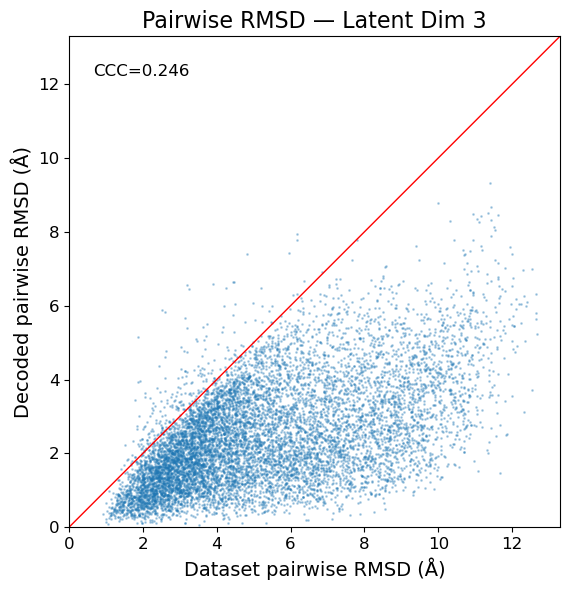

In [9]:
from plots import plot_pairwise_rmsd

rows = []

keys = ["test_trans"]

for run in [3]:
    for var in [3]:
        for key in keys:
            ccc, _, _ = plot_pairwise_rmsd(
                MAs[run][var],
                key=key,
                show_plot=True,
                title=f"Pairwise RMSD — Latent Dim {var}",
                max_pairs=10000,
            )

            rows.append({"var": var, "run": run, "dataset": key, "ccc": ccc})

            MAs[run][var]._decoded.clear()
            MAs[run][var]._encoded.clear()
            gc.collect()
            torch.cuda.empty_cache()

            plt.close("all")


# df_ccc = pd.DataFrame(rows)
# df_ccc_summary = (
#     df_ccc.groupby(["var", "dataset"])["ccc"].agg(["mean", "std"]).reset_index()
# )

# df_ccc_summary.sort_values(["var", "dataset"]).to_csv(
#     "../statistics/pairwise_rmsd_ccc.csv", index=False
# )

#### Dope score as a grid (2D only)

Re-using previously initialised latent grid.


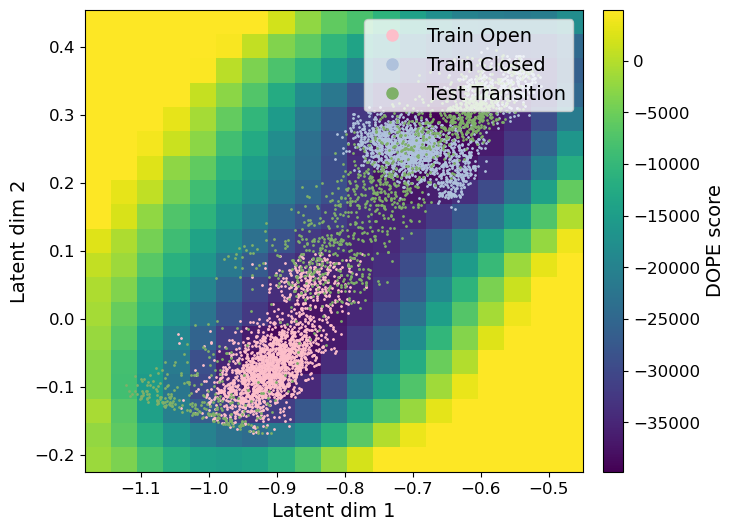

In [44]:
run: int = 1
var: int = 2


if "grid" not in MAs[run][var]._encoded:
    grid_key: str = MAs[run][var].setup_grid(samples=20)
    print(
        f"Latent grid '{grid_key}' initialised with {MAs[run][var].n_samples} samples per axis."
    )
else:
    grid_key: str = "grid"
    print("Re-using previously initialised latent grid.")

refine: bool = True

dope_surface, xvals, yvals = MAs[run][var].scan_dope(refine=refine)
surface_clip: float = np.percentile(dope_surface, 80)

dope_plot_data: list[tuple[str, ...]] = [
    ("train_open", "Train Open", "#FDBFCA", "scatter"),
    ("train_closed", "Train Closed", "#AFC2DC", "scatter"),
    ("test_trans", "Test Transition", "#7FB069", "scatter"),
]

plot_dope_surface(
    MAs[run][var],
    refine=refine,
    truncate_at=surface_clip,
    plot_data=dope_plot_data,
    cmap="viridis",
    bbox_inches="tight",
)

### PCA as a point cloud

Calc Dope: 100%|██████████| 160/160 [00:07<00:00, 20.77it/s]


Latent Dim 2: Total: 100.00%


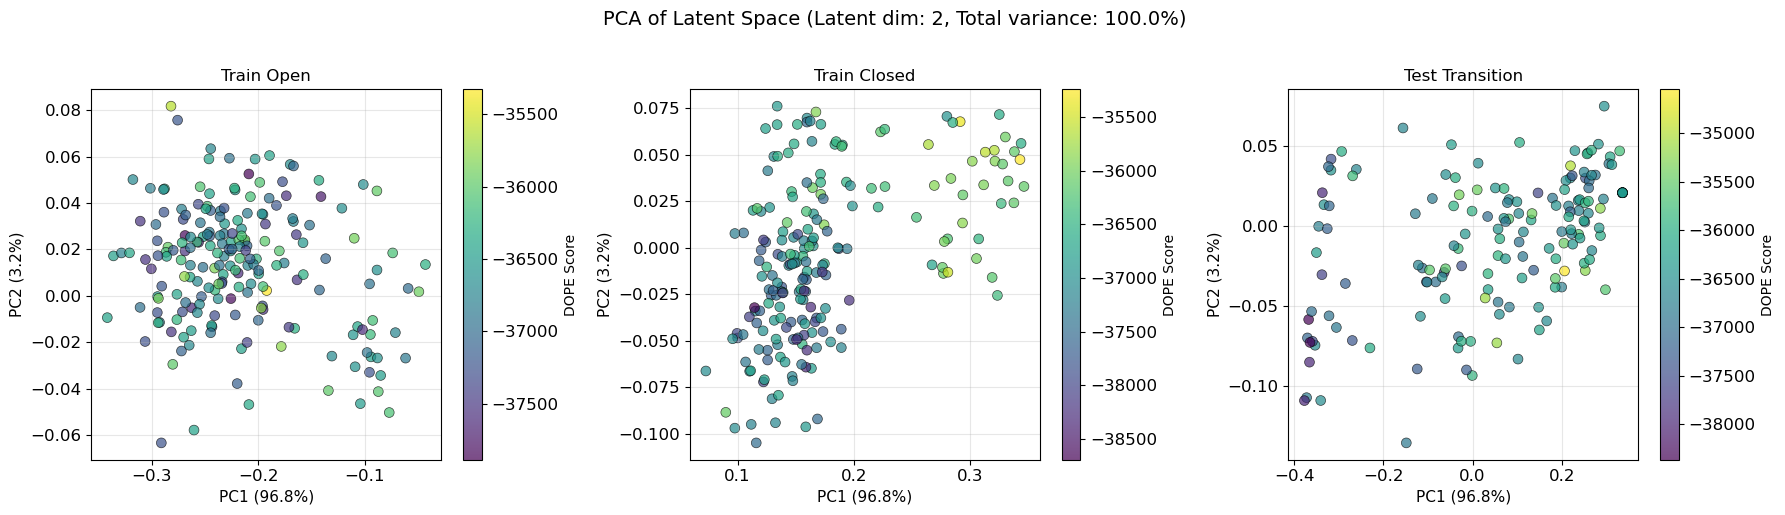

: 

In [ ]:
from sklearn.decomposition import PCA

run: int = 1
ALL_VARS: list[int] = [2, 7]
refine: bool = False
use_partial: bool = True
step: int = 10

dope_scores: dict = {}
pca_results: dict = {}
latent_original_dict: dict = {}


pcas: dict = {}

keys: list[str] = ["train_open", "train_closed", "test_trans"]

for var in ALL_VARS:
    data: dict = {}
    dope_scores[var] = {}
    latent_encodings: dict = {}

    # ============================================================
    # getting datasets, dopescores and latent encodings
    # ============================================================

    for key in keys:
        data[key] = MAs[run][var].get_dataset(key, scale=True)[::step]
        dope_scores[var][key] = MAs[run][var].get_all_dope_score(
            data[key], refine=refine
        )
        latent_encodings[key] = MAs[run][var].get_encoded(key)[::step]

    # ============================================================
    # Applying PCA
    # ============================================================

    pca = PCA(n_components=2)
    pcas[var] = pca

    latent_all: np.ndarray = np.vstack([latent_encodings[key] for key in keys])

    pca.fit(latent_all)

    var_pc1: float = pca.explained_variance_ratio_[0] * 100
    var_pc2: float = pca.explained_variance_ratio_[1] * 100
    var_total: float = var_pc1 + var_pc2

    print(f"Latent Dim {var}: Total: {var_total:.2f}%")

    pca_results[var] = {
        "train_open": pca.transform(latent_encodings["train_open"]),
        "train_closed": pca.transform(latent_encodings["train_closed"]),
        "test_trans": pca.transform(latent_encodings["test_trans"]),
        "var_pc1": var_pc1,
        "var_pc2": var_pc2,
        "var_total": var_total,
    }

    # =============================================================
    # Plotting data
    # =============================================================

    plot_data: PlotData = [
        ("train_open", "Train Open", "#FDBFCA"),
        ("train_closed", "Train Closed", "#AFC2DC"),
        ("test_trans", "Test Transition", "#7FB069"),
    ]

    plot_pca_latent_space(
        pca_results[var],
        dope_scores[var],
        plot_data=plot_data,
        latent_dim=var,
    )

### 3D PCA Plotly

In [ ]:
import plotly.graph_objects as go
from sklearn.decomposition import PCA

var: int = 3

# Get latent encodings
latent_open: np.ndarray = MAs[var].get_encoded("train_open")
latent_closed: np.ndarray = MAs[var].get_encoded("train_closed")
latent_test: np.ndarray = MAs[var].get_encoded("test_trans")
latent_all: np.ndarray = np.vstack([latent_open, latent_closed, latent_test])

# Subsample for performance (adjust step as needed)
step: int = 5
latent_open_sub: np.ndarray = latent_open[::step]
latent_closed_sub: np.ndarray = latent_closed[::step]
latent_test_sub: np.ndarray = latent_test[::step]

# Fit PCA
pca = PCA(n_components=2)
pca.fit(latent_all)

mean: np.ndarray = pca.mean_
pc1: np.ndarray = pca.components_[0]
pc2: np.ndarray = pca.components_[1]

# Create PCA plane mesh
grid_range: int = 3
u: np.ndarray = np.linspace(-grid_range, grid_range, 15)
v: np.ndarray = np.linspace(-grid_range, grid_range, 15)
U: np.ndarray
V: np.ndarray
U, V = np.meshgrid(u, v)

plane_x: np.ndarray = mean[0] + U * pc1[0] + V * pc2[0]
plane_y: np.ndarray = mean[1] + U * pc1[1] + V * pc2[1]
plane_z: np.ndarray = mean[2] + U * pc1[2] + V * pc2[2]

# Create figure
fig = go.Figure()

# Add data points (subsampled)
fig.add_trace(
    go.Scatter3d(
        x=latent_open_sub[:, 0],
        y=latent_open_sub[:, 1],
        z=latent_open_sub[:, 2],
        mode="markers",
        marker={"size": 2, "color": "#FDBFCA", "opacity": 0.7},
        name="Train Open",
    )
)
fig.add_trace(
    go.Scatter3d(
        x=latent_closed_sub[:, 0],
        y=latent_closed_sub[:, 1],
        z=latent_closed_sub[:, 2],
        mode="markers",
        marker={"size": 2, "color": "#AFC2DC", "opacity": 0.7},
        name="Train Closed",
    )
)
fig.add_trace(
    go.Scatter3d(
        x=latent_test_sub[:, 0],
        y=latent_test_sub[:, 1],
        z=latent_test_sub[:, 2],
        mode="markers",
        marker={"size": 2, "color": "#7FB069", "opacity": 0.7},
        name="Test Transition",
    )
)

# Add PCA plane
fig.add_trace(
    go.Surface(
        x=plane_x,
        y=plane_y,
        z=plane_z,
        opacity=0.4,
        colorscale=[[0, "royalblue"], [1, "royalblue"]],
        showscale=False,
        name="PCA Plane",
    )
)

# Add PC vectors as lines
arrow_scale: int = 2
fig.add_trace(
    go.Scatter3d(
        x=[mean[0], mean[0] + pc1[0] * arrow_scale],
        y=[mean[1], mean[1] + pc1[1] * arrow_scale],
        z=[mean[2], mean[2] + pc1[2] * arrow_scale],
        mode="lines",
        line={"color": "red", "width": 6},
        name=f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)",
    )
)
fig.add_trace(
    go.Scatter3d(
        x=[mean[0], mean[0] + pc2[0] * arrow_scale],
        y=[mean[1], mean[1] + pc2[1] * arrow_scale],
        z=[mean[2], mean[2] + pc2[2] * arrow_scale],
        mode="lines",
        line={"color": "orange", "width": 6},
        name=f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)",
    )
)

fig.update_layout(
    title=f"3D Latent Space with PCA Plane<br>Variance explained: {pca.explained_variance_ratio_.sum() * 100:.1f}%",
    scene=dict(
        xaxis_title="Latent 1",
        yaxis_title="Latent 2",
        zaxis_title="Latent 3",
        xaxis={"range": [-1.5, 1.5]},
        yaxis={"range": [-1.5, 1.5]},
        zaxis={"range": [-1.5, 1.5]},
        aspectmode="cube",
    ),
    width=800,
    height=700,
    legend={"x": 0.02, "y": 0.98},
)

fig.show()

## 2D Hyperlatent representations


### Setup

In [13]:
run: int = 2
var: int = 7
N_SAMPLES: int = 20
REFINE: bool = True
TRUNCATE_AT: int = -27000

encoded_test: np.ndarray = MAs[run][var].get_encoded("test_trans").numpy()
encoded_open: np.ndarray = MAs[run][var].get_encoded("train_open").numpy()
encoded_closed: np.ndarray = MAs[run][var].get_encoded("train_closed").numpy()

encoded_datasets = [
    (encoded_test, "Test Transition", TEST_COLOR),
    (encoded_open, "Train Open", OPEN_COLOR),
    (encoded_closed, "Train Closed", CLOSED_COLOR),
]

encoded_all = np.vstack([encoded_test, encoded_open, encoded_closed])

encoding test_trans: 100it [00:00, 302.21it/s]
encoding train_open: 125it [00:00, 257.25it/s]
encoding train_closed: 125it [00:00, 235.12it/s]


### PCA

var1: 78.17940521240234
var2: 15.80345344543457
var total: 93.98285675048828
run: 2, var: 7
Decoding 20x20 = 400 grid points...
Computing DOPE scores...


Calc Dope: 100%|██████████| 400/400 [00:23<00:00, 17.13it/s]


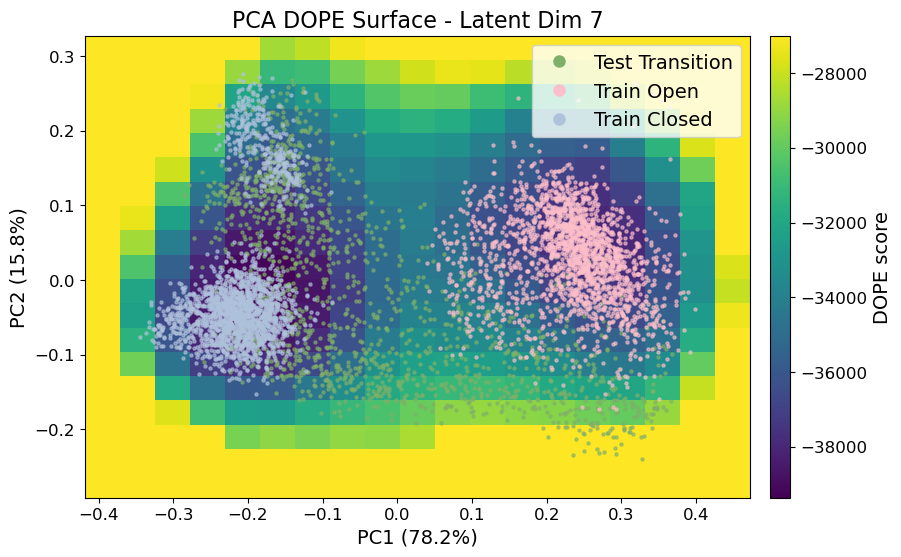

In [14]:
from plots import plot_dope_mesh
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(encoded_all)

var_pc1: float = pca.explained_variance_ratio_[0] * 100
var_pc2: float = pca.explained_variance_ratio_[1] * 100
var_total = var_pc1 + var_pc2


print(f"var1: {var_pc1}")
print(f"var2: {var_pc2}")
print(f"var total: {var_total}")
print(f"run: {run}, var: {var}")


_ = plot_dope_mesh(
    MAs[run][var],
    encoded_datasets=encoded_datasets,
    mapping=pca.transform,
    inverse_mapping=pca.inverse_transform,
    n_samples=N_SAMPLES,
    refine=REFINE,
    truncate_at=TRUNCATE_AT,
    title=f"PCA DOPE Surface - Latent Dim {var}",
    xlabel=f"PC1 ({var_pc1:.1f}%)",
    ylabel=f"PC2 ({var_pc2:.1f}%)",
)

#### PCA Bond Length Plots

Decoding train_both: 250it [00:01, 150.82it/s]
Decoding test_trans: 100it [00:00, 188.11it/s]


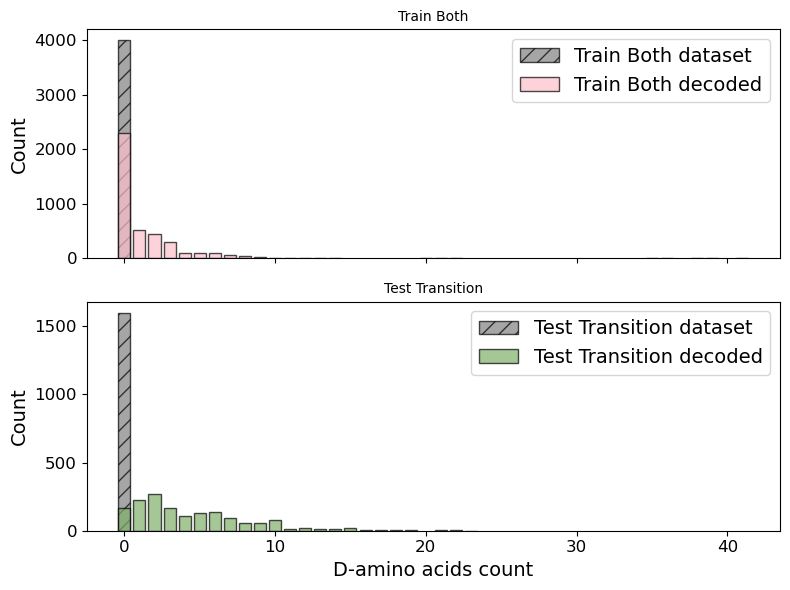

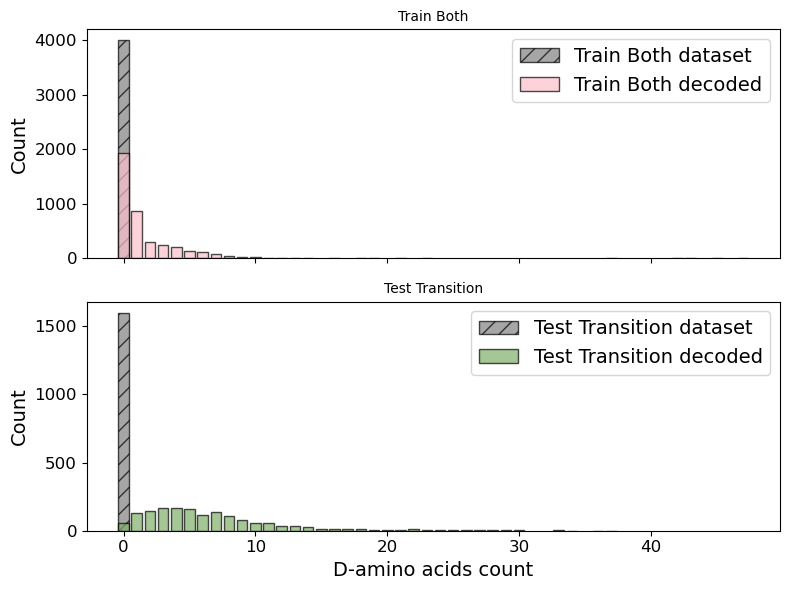

In [ ]:
from utils import make_hyperlatent_ma

hyper_ma = make_hyperlatent_ma(MAs[run][var], pca.transform, pca.inverse_transform)

plot_inversion_hist(MA=hyper_ma, plot_data=plot_data)

plot_inversion_hist(MA=MAs[run][var], plot_data=plot_data)

### UMAP

Decoding 30x30 = 900 grid points...
Computing DOPE scores...


Calc Dope: 100%|██████████| 900/900 [00:54<00:00, 16.46it/s]


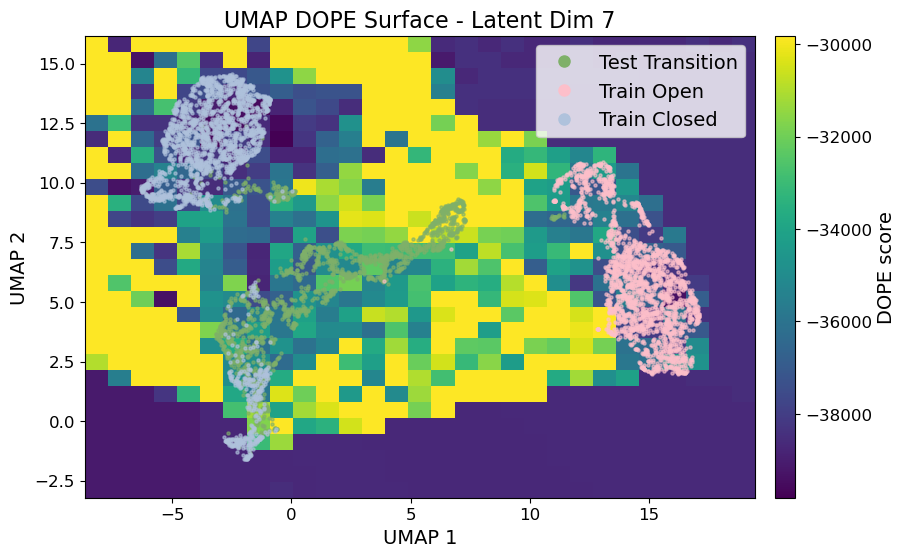

In [ ]:
import umap
from plots import plot_dope_mesh

reducer = umap.UMAP(
    n_components=2, random_state=RANDOM_STATE, n_neighbors=12, min_dist=0.1
)

reducer.fit(np.vstack([encoded_open, encoded_closed, encoded_test]))

_ = plot_dope_mesh(
    MAs[run][var],
    encoded_datasets=encoded_datasets,
    mapping=reducer.transform,
    inverse_mapping=reducer.inverse_transform,
    n_samples=N_SAMPLES,
    refine=REFINE,
    title=f"UMAP DOPE Surface - Latent Dim {var}",
    xlabel="UMAP 1",
    ylabel="UMAP 2",
)

### Autoencoder offline
Where N = number of conformations and D = latent_dim (dimensionality of models latent space) the autoencoder:

- takes two inputs:
    - dataset in original N x 2145 x 3 cartesian space
    - encoded data in N x 1 x D latent space
- outputs: 
    - hyperlatent representation in N x 1 x 2 space
    - encoded data in N x 1 x D space

The flow of data would be D -> 2 -> D so this autoencoder should work bidirectionally. 

#### Train loop

In [10]:
from analysis.utils import LatentAutoencoder, TrainConfig, dual_rmsd_loss, train_loop

KEY = "test_trans"

ma = MAs[run][var]
loss_func = dual_rmsd_loss(ma)

model = LatentAutoencoder(input_dim=var)
config = TrainConfig(ma=ma, model=model, key=KEY, epochs=300, loss_func=loss_func)

model = train_loop(config)

ModuleNotFoundError: No module named 'analysis'

#### Plotting

Decoding 30x30 = 900 grid points...
Computing DOPE scores...


Calc Dope: 100%|██████████| 900/900 [00:54<00:00, 16.58it/s]


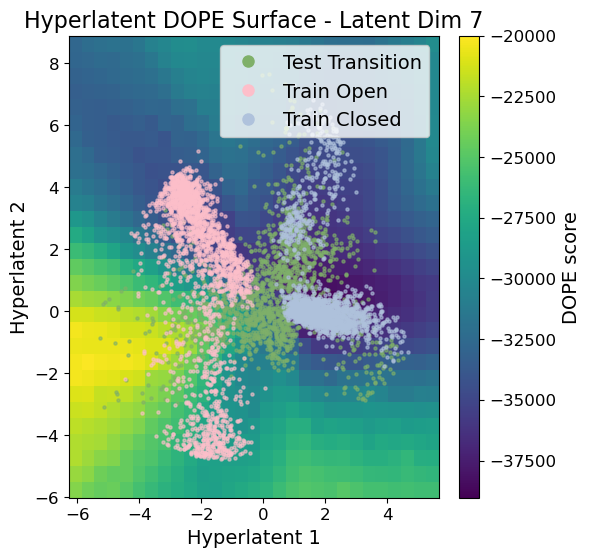

In [ ]:
from plots import plot_dope_mesh

model.eval()


def ae_encode(x: np.ndarray) -> np.ndarray:
    with torch.no_grad():
        return model.encode(torch.tensor(x, dtype=torch.float32)).numpy()


def ae_decode(x: np.ndarray) -> np.ndarray:
    with torch.no_grad():
        return model.decode(torch.tensor(x, dtype=torch.float32)).numpy()


_ = plot_dope_mesh(
    MAs[run][var],
    encoded_datasets=encoded_datasets,
    mapping=ae_encode,
    inverse_mapping=ae_decode,
    n_samples=N_SAMPLES,
    refine=REFINE,
    truncate_at=TRUNCATE_AT,
    title=f"Hyperlatent DOPE Surface - Latent Dim {var}",
    xlabel="Hyperlatent 1",
    ylabel="Hyperlatent 2",
)

#### Path-finding through latent space

Find a minimal-DOPE-cost path between closed and open states using A* search.


In [ ]:
from path_finder import find_path
from plots import plot_path_on_mesh

# Select random exemplars from closed and open sets
closed_idx: int = np.random.randint(0, len(encoded_closed))
open_idx: int = np.random.randint(0, len(encoded_open))

start_encoded: np.ndarray = encoded_closed[closed_idx]
end_encoded: np.ndarray = encoded_open[open_idx]

print(f"Finding path from Closed[{closed_idx}] to Open[{open_idx}]")
print(f"Grid size: {N_SAMPLES**2} (smaller = finer search, slower)")
print("This may take a minute...")

path, path_info = find_path(
    start_encoded,
    end_encoded,
    MAs[run][var],
    mapping=ae_encode,
    inverse_mapping=ae_decode,
    refine=REFINE,
    grid_size=0.3,
    heuristic_weight=1.5,
    max_iterations=5000,
)

print(f"\nPath found: {path_info['success']}")
print(f"  Nodes expanded: {path_info['nodes_expanded']}")
print(f"  Total DOPE cost: {path_info['path_dope_cost']:.1f}")

if path_info["success"]:
    print(f"  Path length: {len(path)} steps")

Finding path from Closed[1518] to Open[21]
Grid size: 900 (smaller = finer search, slower)
This may take a minute...


Calc Dope:   0%|          | 0/1 [00:00<?, ?it/s]Process SpawnPoolWorker-3:
Process SpawnPoolWorker-1:
Process SpawnPoolWorker-4:
Traceback (most recent call last):
  File "/home/brian-daniel/miniconda3/envs/molearn/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/brian-daniel/miniconda3/envs/molearn/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/home/brian-daniel/miniconda3/envs/molearn/lib/python3.11/multiprocessing/pool.py", line 114, in worker
    task = get()
           ^^^^^
  File "/home/brian-daniel/miniconda3/envs/molearn/lib/python3.11/multiprocessing/queues.py", line 364, in get
    with self._rlock:
  File "/home/brian-daniel/miniconda3/envs/molearn/lib/python3.11/multiprocessing/synchronize.py", line 95, in __enter__
    return self._semlock.__enter__()
           ^^^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt
Traceback (most recent call last):
Traceback (most r

KeyboardInterrupt: 

In [ ]:
if path_info["success"]:
    fig, ax = plt.subplots(figsize=(10, 6))

    # Replot the mesh
    _, d1_vals, d2_vals = plot_dope_mesh(
        MAs[run][var],
        encoded_datasets=encoded_datasets,
        mapping=ae_encode,
        inverse_mapping=ae_decode,
        n_samples=N_SAMPLES,
        refine=REFINE,
        truncate_at=TRUNCATE_AT,
        title=f"Hyperlatent Path: Closed → Open (Latent Dim {var})",
        xlabel="Hyperlatent 1",
        ylabel="Hyperlatent 2",
    )

    ax = plt.gca()
    plot_path_on_mesh(
        path,
        mapping=ae_encode,
        ax=ax,
        color="crimson",
        linewidth=2.5,
        marker_size=10,
        label=f"A* Path (cost={path_info['path_dope_cost']:.0f})",
    )
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()
else:
    print("No path found. Try increasing max_iterations or grid_size.")